# Titanic EDA for exp002

この notebook は EDA に特化して、次に試す仮説を作るためのものです。

今回の目的:
- `train.csv` と `test.csv` の欠損と分布差を確認する
- 主要列と `Survived` の関係を観察する
- 次に試す仮説を 2-3 個に絞る

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 100)

cwd = Path.cwd().resolve()
if cwd.name == "notebooks":
    COMP_DIR = cwd.parent
elif cwd.name == "titanic":
    COMP_DIR = cwd
else:
    COMP_DIR = Path("/home/sora/dev/kaggle/competitions/titanic")

DATA_DIR = COMP_DIR / "data"
TRAIN_PATH = DATA_DIR / "train.csv"
TEST_PATH = DATA_DIR / "test.csv"

In [2]:
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print("train shape:", train_df.shape)
print("test shape:", test_df.shape)
display(train_df.head())

train shape: (891, 12)
test shape: (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Missing Values

`train` と `test` の両方で欠損率を見て、補完方針や train/test 差の候補を探します。

In [3]:
missing_train = pd.DataFrame(
    {
        "missing": train_df.isna().sum(),
        "missing_rate": (train_df.isna().mean() * 100).round(2),
    }
).sort_values("missing", ascending=False)

missing_test = pd.DataFrame(
    {
        "missing": test_df.isna().sum(),
        "missing_rate": (test_df.isna().mean() * 100).round(2),
    }
).sort_values("missing", ascending=False)

print("train missing")
display(missing_train)
print("test missing")
display(missing_test)

train missing


,missing,missing_rate
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22
PassengerId,0,0.00
Name,0,0.00
Pclass,0,0.00
Survived,0,0.00
Sex,0,0.00
Parch,0,0.00
SibSp,0,0.00


test missing


,missing,missing_rate
Cabin,327,78.23
Age,86,20.57
Fare,1,0.24
Name,0,0.00
Pclass,0,0.00
PassengerId,0,0.00
Sex,0,0.00
Parch,0,0.00
SibSp,0,0.00
Ticket,0,0.00


`Cabin(客室情報)`と`Age(年齢)`の欠損があり、その欠損率は多少の差はあるものの、訓練データとテストデータにおいて、問題になるほど大きな不均衡はなさそう

In [4]:
focus_cols = ["Age", "Cabin", "Embarked", "Fare"]
focus_missing = pd.DataFrame(
    {
        "train_missing": train_df[focus_cols].isna().sum(),
        "train_missing_rate": (train_df[focus_cols].isna().mean() * 100).round(2),
        "test_missing": test_df[focus_cols].isna().sum(),
        "test_missing_rate": (test_df[focus_cols].isna().mean() * 100).round(2),
    }
)
display(focus_missing)

,train_missing,train_missing_rate,test_missing,test_missing_rate
Age,177,19.87,86,20.57
Cabin,687,77.10,327,78.23
Embarked,2,0.22,0,0.00
Fare,0,0.00,1,0.24


## Target Distribution

まずは `Survived` のバランスを確認します。

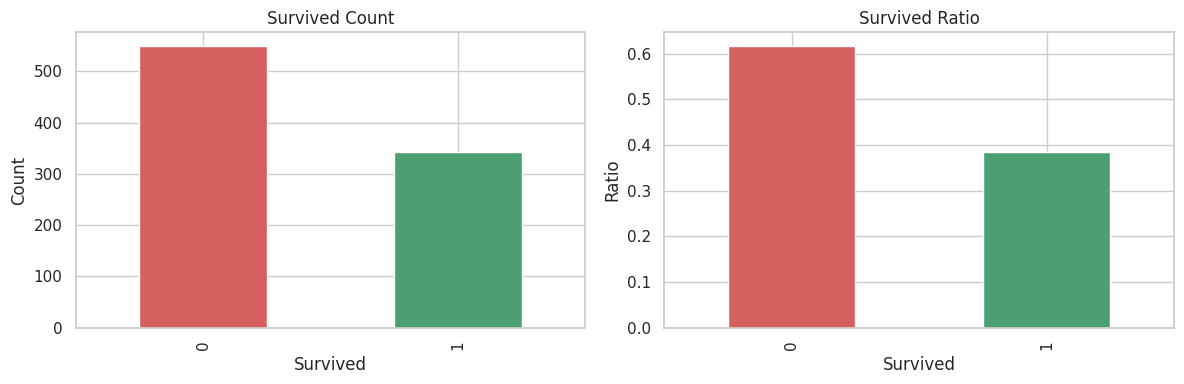

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

train_df["Survived"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color=["#d65f5f", "#4c9f70"])
axes[0].set_title("Survived Count")
axes[0].set_xlabel("Survived")
axes[0].set_ylabel("Count")

train_df["Survived"].value_counts(normalize=True).sort_index().plot(kind="bar", ax=axes[1], color=["#d65f5f", "#4c9f70"])
axes[1].set_title("Survived Ratio")
axes[1].set_xlabel("Survived")
axes[1].set_ylabel("Ratio")

plt.tight_layout()
plt.show()

## Categorical Features vs Target

カテゴリ列ごとの生存率と件数を見ます。

In [6]:
for col in ["Sex", "Pclass", "Embarked"]:
    print(f"=== {col} ===")
    summary = train_df.groupby(col, dropna=False)["Survived"].agg(["mean", "count"]).sort_values("mean", ascending=False)
    display(summary)


=== Sex ===


,mean,count
Sex,,
female,0.742038,314
male,0.188908,577


=== Pclass ===


,mean,count
Pclass,,
1,0.629630,216
2,0.472826,184
3,0.242363,491


=== Embarked ===


,mean,count
Embarked,,
NaN,1.000000,2
C,0.553571,168
Q,0.389610,77
S,0.336957,644


/tmp/ipykernel_82458/3485271721.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=train_df, x="Sex", y="Survived", ax=axes[0], palette="Set2")
/tmp/ipykernel_82458/3485271721.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=train_df, x="Pclass", y="Survived", ax=axes[1], palette="Blues")
/tmp/ipykernel_82458/3485271721.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=embarked_plot_df, x="Embarked", y="Survived", ax=axes[2], palette="Greens")


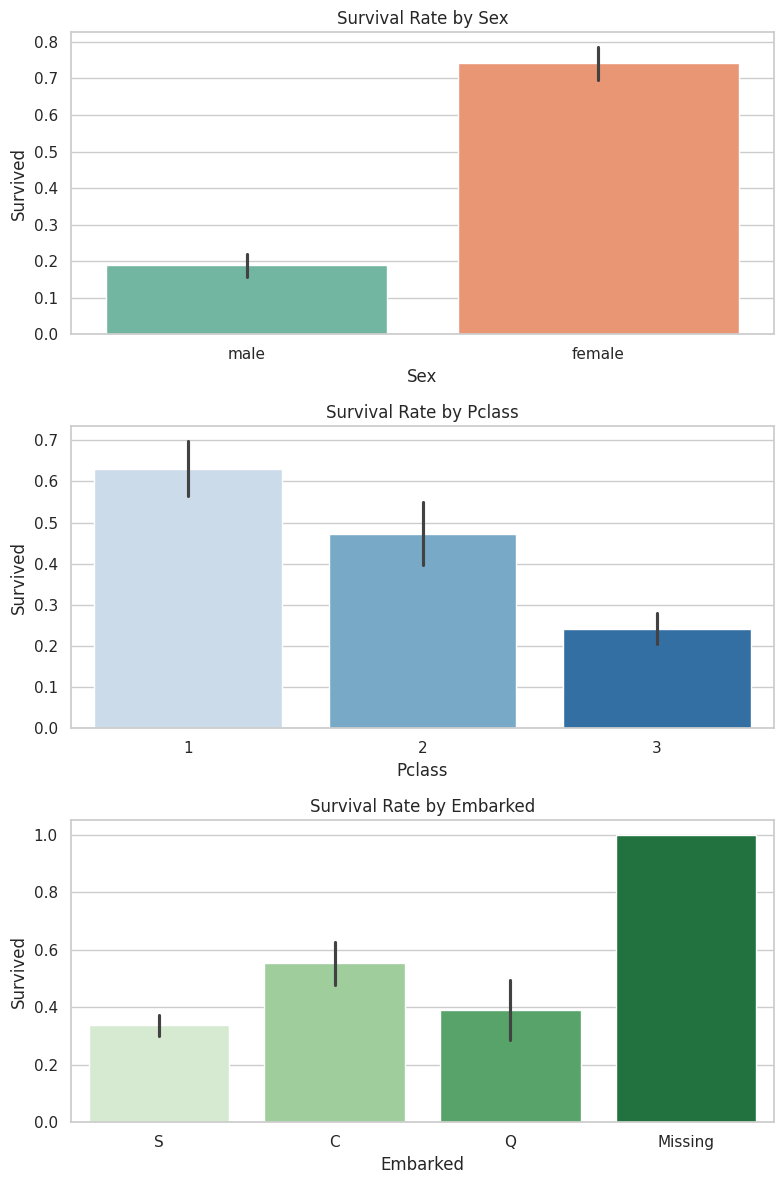

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(8, 12))

sns.barplot(data=train_df, x="Sex", y="Survived", ax=axes[0], palette="Set2")
axes[0].set_title("Survival Rate by Sex")
axes[0].set_xlabel("Sex")
axes[0].set_ylabel("Survived")

sns.barplot(data=train_df, x="Pclass", y="Survived", ax=axes[1], palette="Blues")
axes[1].set_title("Survival Rate by Pclass")
axes[1].set_xlabel("Pclass")
axes[1].set_ylabel("Survived")

embarked_plot_df = train_df.copy()
embarked_plot_df["Embarked"] = embarked_plot_df["Embarked"].fillna("Missing")
sns.barplot(data=embarked_plot_df, x="Embarked", y="Survived", ax=axes[2], palette="Greens")
axes[2].set_title("Survival Rate by Embarked")
axes[2].set_xlabel("Embarked")
axes[2].set_ylabel("Survived")

plt.tight_layout()
plt.show()


## Numeric Features

年齢と運賃は連続値のまま見るだけでなく、帯にして観察します。

In [14]:
train_age = train_df.copy()
train_age["AgeBand"] = pd.cut(train_age["Age"], bins=[0, 12, 18, 25, 35, 50, 80])
display(train_age.groupby("AgeBand", observed=False)["Survived"].agg(["mean", "count"]))

train_fare = train_df.copy()
train_fare["FareBand"] = pd.qcut(train_fare["Fare"], q=4, duplicates="drop")
display(train_fare.groupby("FareBand", observed=False)["Survived"].agg(["mean", "count"]))

,mean,count
AgeBand,,
"(0, 12]",0.579710,69
"(12, 18]",0.428571,70
"(18, 25]",0.333333,162
"(25, 35]",0.423469,196
"(35, 50]",0.398693,153
"(50, 80]",0.343750,64


,mean,count
FareBand,,
"(-0.001, 7.91]",0.197309,223
"(7.91, 14.454]",0.303571,224
"(14.454, 31.0]",0.454955,222
"(31.0, 512.329]",0.581081,222


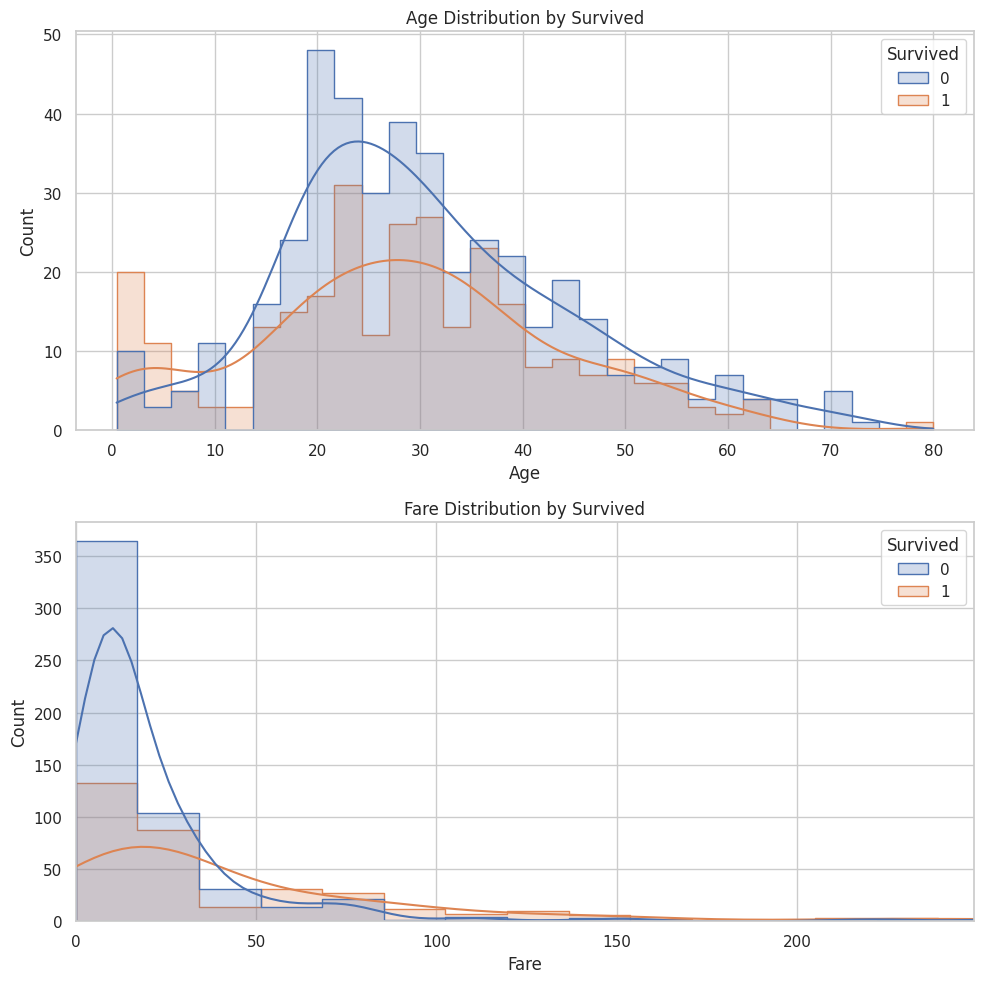

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(10, 10))

sns.histplot(
    data=train_df,
    x="Age",
    hue="Survived",
    bins=30,
    kde=True,
    ax=axes[0],
    element="step"
)
axes[0].set_title("Age Distribution by Survived")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Count")

sns.histplot(
    data=train_df,
    x="Fare",
    hue="Survived",
    bins=30,
    kde=True,
    ax=axes[1],
    element="step"
)
axes[1].set_title("Fare Distribution by Survived")
axes[1].set_xlabel("Fare")
axes[1].set_ylabel("Count")
axes[1].set_xlim(0, train_df["Fare"].quantile(0.99))

plt.tight_layout()
plt.show()

## Family Features

`SibSp` と `Parch` から家族サイズを作って観察します。

In [15]:
train_family = train_df.copy()
train_family["FamilySize"] = train_family["SibSp"] + train_family["Parch"] + 1
train_family["IsAlone"] = (train_family["FamilySize"] == 1).astype(int)

display(train_family.groupby("FamilySize")["Survived"].agg(["mean", "count"]))
display(train_family.groupby("IsAlone")["Survived"].agg(["mean", "count"]))

,mean,count
FamilySize,,
1,0.303538,537
2,0.552795,161
3,0.578431,102
4,0.724138,29
5,0.200000,15
6,0.136364,22
7,0.333333,12
8,0.000000,6
11,0.000000,7


,mean,count
IsAlone,,
0,0.505650,354
1,0.303538,537


/tmp/ipykernel_82458/1305597562.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=train_family, x="FamilySize", y="Survived", ax=axes[0],
/tmp/ipykernel_82458/1305597562.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=train_family, x="IsAlone", y="Survived", ax=axes[1],
/tmp/ipykernel_82458/1305597562.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(["Not Alone", "Alone"])


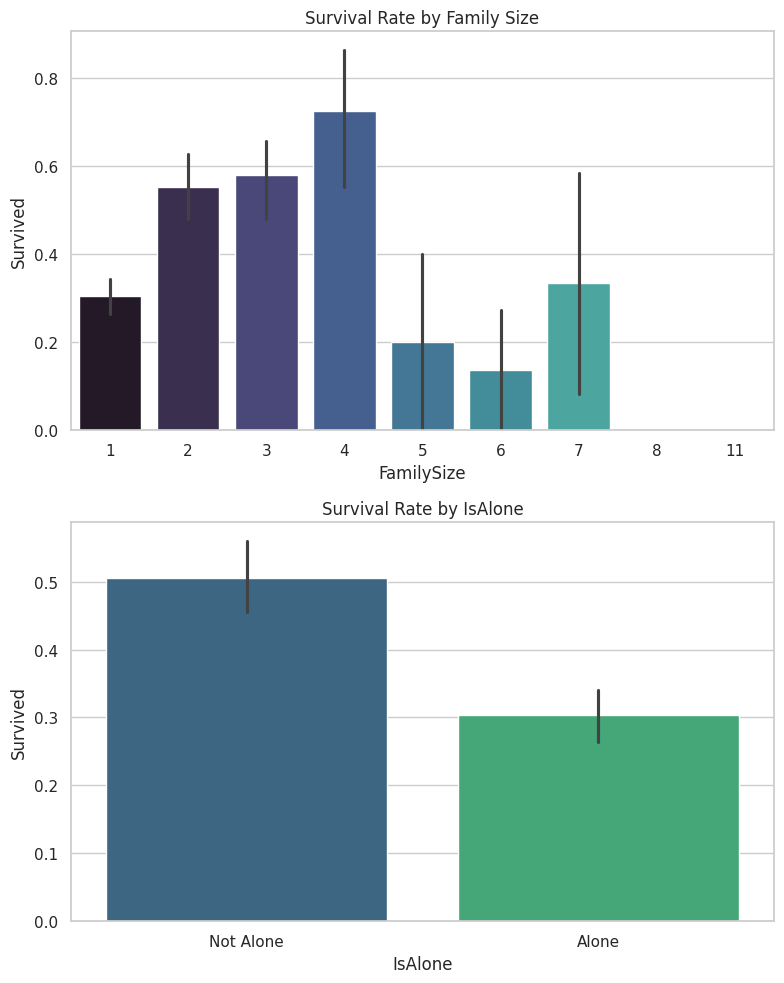

In [17]:
fig, axes = plt.subplots(2, 1, figsize=(8, 10))

sns.barplot(data=train_family, x="FamilySize", y="Survived", ax=axes[0],
palette="mako")
axes[0].set_title("Survival Rate by Family Size")
axes[0].set_xlabel("FamilySize")
axes[0].set_ylabel("Survived")

sns.barplot(data=train_family, x="IsAlone", y="Survived", ax=axes[1],
palette="viridis")
axes[1].set_title("Survival Rate by IsAlone")
axes[1].set_xlabel("IsAlone")
axes[1].set_ylabel("Survived")
axes[1].set_xticklabels(["Not Alone", "Alone"])

plt.tight_layout()
plt.show()

## Cabin and Name Clues

文字列列はまず単純な派生だけ観察します。

In [18]:
train_text = train_df.copy()
train_text["HasCabin"] = train_text["Cabin"].notna().astype(int)
train_text["Title"] = train_text["Name"].str.extract(r",\s*([^\.]+)\.", expand=False).fillna("Unknown")

display(train_text.groupby("HasCabin")["Survived"].agg(["mean", "count"]))
display(train_text.groupby("Title")["Survived"].agg(["mean", "count"]).sort_values("count", ascending=False).head(15))

,mean,count
HasCabin,,
0,0.299854,687
1,0.666667,204


,mean,count
Title,,
Mr,0.156673,517
Miss,0.697802,182
Mrs,0.792000,125
Master,0.575000,40
Dr,0.428571,7
Rev,0.000000,6
Mlle,1.000000,2
Major,0.500000,2
Col,0.500000,2


/tmp/ipykernel_82458/1614681003.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=train_text, x="HasCabin", y="Survived", ax=axes[0],
/tmp/ipykernel_82458/1614681003.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["No Cabin", "Has Cabin"])
/tmp/ipykernel_82458/1614681003.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=title_plot_df, x="Title", y="Survived", ax=axes[1],


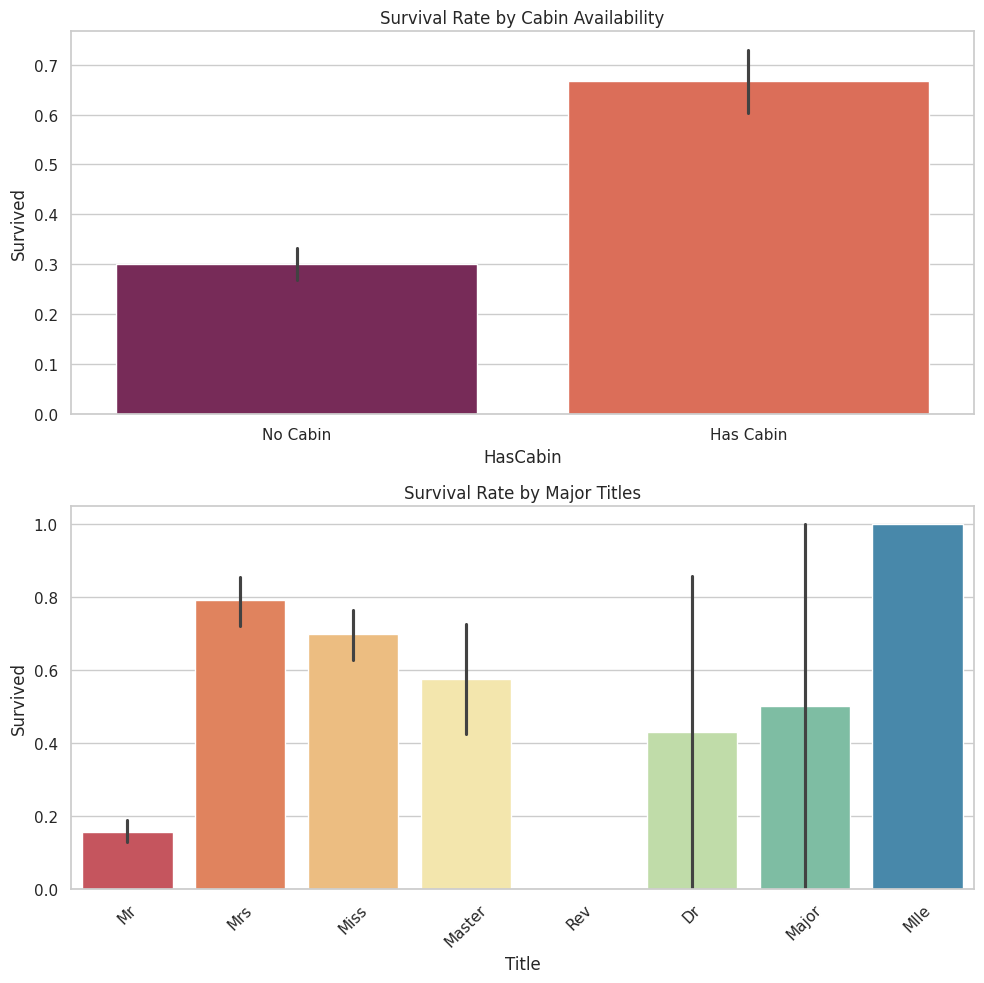

In [20]:
fig, axes = plt.subplots(2, 1, figsize=(10, 10))

sns.barplot(data=train_text, x="HasCabin", y="Survived", ax=axes[0],
palette="rocket")
axes[0].set_title("Survival Rate by Cabin Availability")
axes[0].set_xlabel("HasCabin")
axes[0].set_ylabel("Survived")
axes[0].set_xticklabels(["No Cabin", "Has Cabin"])

top_titles = train_text["Title"].value_counts().head(8).index
title_plot_df = train_text[train_text["Title"].isin(top_titles)].copy()
sns.barplot(data=title_plot_df, x="Title", y="Survived", ax=axes[1],
palette="Spectral")
axes[1].set_title("Survival Rate by Major Titles")
axes[1].set_xlabel("Title")
axes[1].set_ylabel("Survived")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## Train vs Test Distribution Check

`Age` と `Fare` の train/test 差を軽く見ておきます。

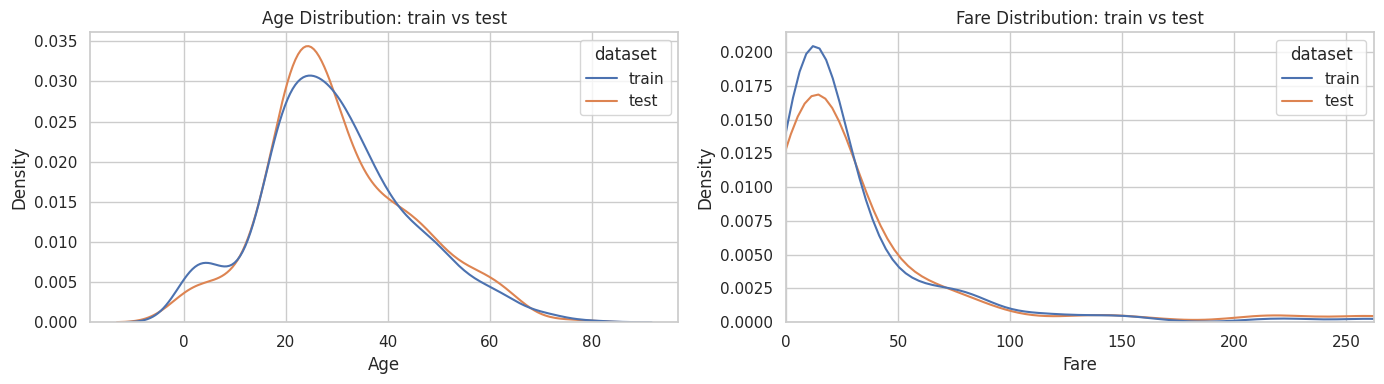

In [21]:
compare_df = pd.concat(
    [
        train_df[["Age", "Fare"]].assign(dataset="train"),
        test_df[["Age", "Fare"]].assign(dataset="test"),
    ],
    ignore_index=True,
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.kdeplot(data=compare_df, x="Age", hue="dataset", ax=axes[0], common_norm=False)
axes[0].set_title("Age Distribution: train vs test")

sns.kdeplot(data=compare_df, x="Fare", hue="dataset", ax=axes[1], common_norm=False)
axes[1].set_title("Fare Distribution: train vs test")
axes[1].set_xlim(0, compare_df["Fare"].quantile(0.99))

plt.tight_layout()
plt.show()

## Hypothesis Notes

このセルは実行セルではなく、観察結果を見ながら手で更新する想定です。

仮説候補の例:
1. `Cabin` の有無は生存率と強く関係していそう
2. `Title` は `Sex` や `Age` と独立に追加情報を持っていそう
3. `FamilySize` は単独乗船かどうかの方が効く可能性がある

次にやること:
- 仮説を 1 つだけ選ぶ
- その仮説だけを次の notebook か `src` 側で検証する
- `exp002.md` に観察内容と次アクションを書く
